# 03 – Tổng hợp và so sánh các kỹ thuật Feature Selection


In [1]:
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings('ignore')

ROOT = Path.cwd()
if not (ROOT / 'data/processed').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
DATA, FIG = ROOT / 'data/processed', ROOT / 'figures'
FIG.mkdir(exist_ok=True)

from src.merge_results import load, ranking, MODELS, TECHNIQUES
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': .3})
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 30)

## 1. Gộp và kiểm tra kết quả

In [2]:
merged, errors = load()
assert not errors, 'Còn lỗi, trả lại thành viên sửa:\n - ' + '\n - '.join(errors)
assert len(merged) == 18
merged.to_csv(DATA / 'feature_selection_results.csv', index=False)
print('OK: 18 dòng, đã ghi data/processed/feature_selection_results.csv')
rk = ranking(merged)

OK: 18 dòng, đã ghi data/processed/feature_selection_results.csv


## 2. Bảng 7.1 – CV log RMSE, % thay đổi so với baseline, thời gian

In [3]:
tech_order = {t: i for i, t in enumerate(TECHNIQUES)}
tbl = rk.assign(_o=rk.technique.map(tech_order)).sort_values(['model', '_o']).drop(columns='_o')
cols = ['model', 'technique', 'n_features', 'cv_log_rmse', 'cv_log_rmse_std', 'pct_vs_baseline',
        'test_log_rmse', 'test_original_rmse', 'test_original_r2', 'cv_seconds', 'train_seconds', 'rank']
table_7_1 = tbl[cols].round(4)
table_7_1.to_csv(DATA / 'table_7_1.csv', index=False)
display(table_7_1)

,model,technique,n_features,cv_log_rmse,cv_log_rmse_std,pct_vs_baseline,test_log_rmse,test_original_rmse,test_original_r2,cv_seconds,train_seconds,rank
1,RandomForest,baseline,262,0.1301,0.0147,0.0000,0.1388,22379.6502,0.9093,10.0377,2.3861,2
5,RandomForest,filter_kbest,50,0.1358,0.0150,4.3283,0.1463,23140.7745,0.9031,5.1557,1.1733,6
4,RandomForest,filter_mi,50,0.1320,0.0152,1.4217,0.1418,22461.2025,0.9087,11.1793,2.6080,5
3,RandomForest,wrapper_rfe,50,0.1305,0.0145,0.2793,0.1399,22188.7041,0.9109,84.0588,20.6211,4
0,RandomForest,embedded_lasso,50,0.1293,0.0134,-0.6845,0.1362,21592.5042,0.9156,6.2415,1.7883,1
2,RandomForest,embedded_rf,50,0.1303,0.0150,0.1479,0.1403,22184.4470,0.9109,7.6308,1.7782,3
7,SVR,baseline,262,0.1183,0.0109,0.0000,0.1220,20351.7845,0.9250,0.6450,0.1213,2
10,SVR,filter_kbest,50,0.1293,0.0132,9.3146,0.1470,23389.5918,0.9010,0.2895,0.0593,5
9,SVR,filter_mi,50,0.1215,0.0126,2.7388,0.1339,21647.7482,0.9152,6.1473,1.3707,4
11,SVR,wrapper_rfe,50,0.1335,0.0110,12.8498,0.1322,24033.1357,0.8954,0.4534,0.0742,6


## 3. Mức nhiễu – chênh lệch nào đáng tin?

TV3 và TV4 đã lưu độ lệch chuẩn giữa 5 fold (`cv_log_rmse_std`). Sai số chuẩn của trung bình CV xấp xỉ `std / √5`.
Notebook dùng **std của baseline cùng mô hình** làm mức nhiễu tham khảo (vì TV5 chưa xuất std cho Embedded).
Đây là ngưỡng *tham khảo*, không phải kiểm định thống kê.

In [4]:
base = rk[rk.technique == 'baseline'].set_index('model')
noise = (base['cv_log_rmse_std'] / np.sqrt(5)).rename('noise_se')
rk2 = rk.join(noise, on='model')
rk2['delta_abs'] = rk2['cv_log_rmse'] - rk2['model'].map(base['cv_log_rmse'])
rk2['verdict'] = np.where(rk2.technique == 'baseline', '-',
                  np.where(rk2.delta_abs.abs() <= rk2.noise_se, 'trong mức nhiễu',
                  np.where(rk2.delta_abs < 0, 'tốt hơn baseline', 'kém hơn baseline')))
display(rk2.loc[rk2.technique != 'baseline', ['model', 'technique', 'delta_abs', 'pct_vs_baseline', 'noise_se', 'verdict']]
        .sort_values(['model', 'delta_abs']).round(4).reset_index(drop=True))

,model,technique,delta_abs,pct_vs_baseline,noise_se,verdict
0,RandomForest,embedded_lasso,-0.0009,-0.6845,0.0066,trong mức nhiễu
1,RandomForest,embedded_rf,0.0002,0.1479,0.0066,trong mức nhiễu
2,RandomForest,wrapper_rfe,0.0004,0.2793,0.0066,trong mức nhiễu
3,RandomForest,filter_mi,0.0019,1.4217,0.0066,trong mức nhiễu
4,RandomForest,filter_kbest,0.0056,4.3283,0.0066,trong mức nhiễu
5,SVR,embedded_lasso,-0.0037,-3.1198,0.0049,trong mức nhiễu
6,SVR,embedded_rf,0.0005,0.4402,0.0049,trong mức nhiễu
7,SVR,filter_mi,0.0032,2.7388,0.0049,trong mức nhiễu
8,SVR,filter_kbest,0.0110,9.3146,0.0049,kém hơn baseline
9,SVR,wrapper_rfe,0.0152,12.8498,0.0049,kém hơn baseline


## 4. Hình tổng hợp (lưu vào `figures/`, tên bắt đầu bằng `fig7_`)

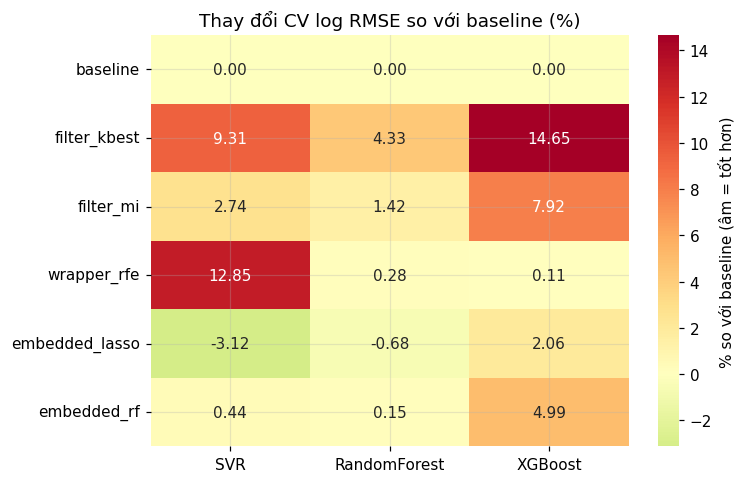

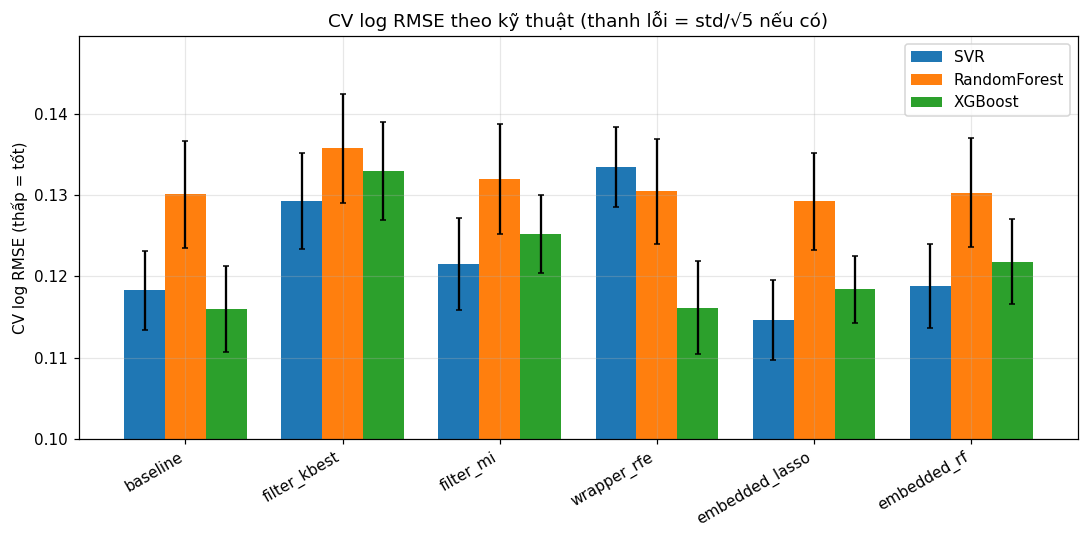

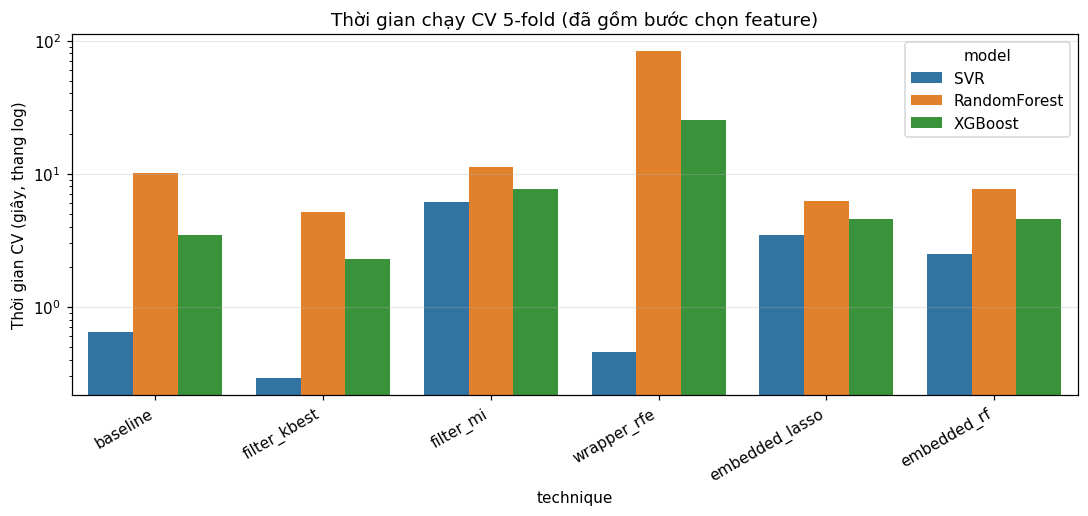

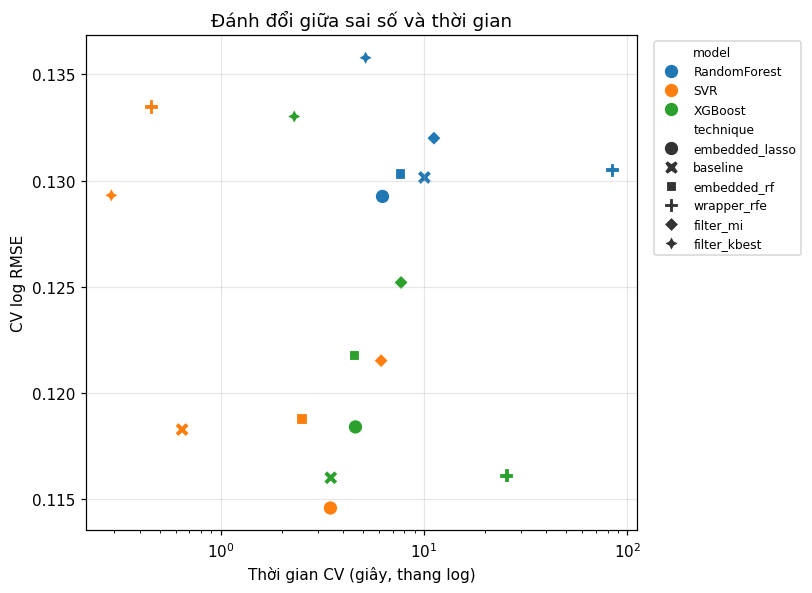

In [5]:
order = TECHNIQUES
# 4.1 Heatmap % thay đổi so với baseline
piv = rk.pivot(index='technique', columns='model', values='pct_vs_baseline').loc[order, MODELS]
plt.figure(figsize=(7, 4.5))
sns.heatmap(piv, annot=True, fmt='.2f', cmap='RdYlGn_r', center=0, cbar_kws={'label': '% so với baseline (âm = tốt hơn)'})
plt.title('Thay đổi CV log RMSE so với baseline (%)'); plt.ylabel(''); plt.xlabel('')
plt.tight_layout(); plt.savefig(FIG / 'fig7_delta_heatmap.png', dpi=150); plt.show()

# 4.2 CV log RMSE theo kỹ thuật (có thanh lỗi nếu có std)
fig, ax = plt.subplots(figsize=(10, 5))
w = 0.26
for i, m in enumerate(MODELS):
    sub = rk[rk.model == m].set_index('technique').loc[order]
    ax.bar(np.arange(len(order)) + (i - 1) * w, sub.cv_log_rmse, w, label=m,
           yerr=sub.cv_log_rmse_std.fillna(0).values / np.sqrt(5), capsize=2)
ax.set_xticks(range(len(order))); ax.set_xticklabels(order, rotation=30, ha='right')
ax.set_ylabel('CV log RMSE (thấp = tốt)'); ax.set_ylim(0.10, None); ax.legend()
ax.set_title('CV log RMSE theo kỹ thuật (thanh lỗi = std/√5 nếu có)')
plt.tight_layout(); plt.savefig(FIG / 'fig7_rmse_by_technique.png', dpi=150); plt.show()

# 4.3 Thời gian CV (thang log)
plt.figure(figsize=(10, 4.8))
sns.barplot(data=rk, x='technique', y='cv_seconds', hue='model', order=order, hue_order=MODELS)
plt.yscale('log'); plt.xticks(rotation=30, ha='right'); plt.ylabel('Thời gian CV (giây, thang log)')
plt.title('Thời gian chạy CV 5-fold (đã gồm bước chọn feature)')
plt.tight_layout(); plt.savefig(FIG / 'fig7_time_comparison.png', dpi=150); plt.show()

# 4.4 Đánh đổi sai số – thời gian
plt.figure(figsize=(7.5, 5.5))
sns.scatterplot(data=rk, x='cv_seconds', y='cv_log_rmse', hue='model', style='technique', s=90)
plt.xscale('log'); plt.xlabel('Thời gian CV (giây, thang log)'); plt.ylabel('CV log RMSE')
plt.title('Đánh đổi giữa sai số và thời gian'); plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout(); plt.savefig(FIG / 'fig7_tradeoff.png', dpi=150); plt.show()

## 5. Quét k của nhóm Filter (dữ liệu của TV4)

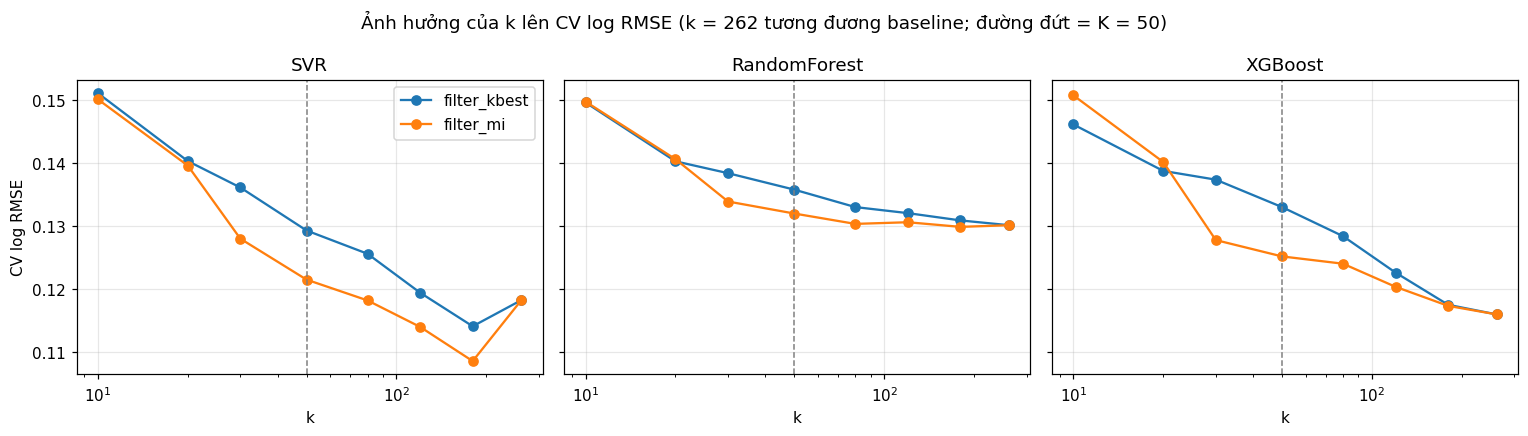

,technique,model,k,cv_log_rmse
0,filter_kbest,RandomForest,262,0.1301
1,filter_kbest,SVR,180,0.1141
2,filter_kbest,XGBoost,262,0.1160
3,filter_mi,RandomForest,180,0.1299
4,filter_mi,SVR,180,0.1086
5,filter_mi,XGBoost,262,0.1160


In [6]:
ks_path = DATA / 'k_sweep_filter.csv'
if ks_path.exists():
    ks = pd.read_csv(ks_path)
    fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
    for ax, m in zip(axes, MODELS):
        for t, g in ks[ks.model == m].groupby('technique'):
            g = g.sort_values('k'); ax.plot(g.k, g.cv_log_rmse, marker='o', label=t)
        ax.axvline(50, ls='--', c='gray', lw=1); ax.set_title(m); ax.set_xlabel('k'); ax.set_xscale('log')
    axes[0].set_ylabel('CV log RMSE'); axes[0].legend()
    plt.suptitle('Ảnh hưởng của k lên CV log RMSE (k = 262 tương đương baseline; đường đứt = K = 50)')
    plt.tight_layout(); plt.savefig(FIG / 'fig7_k_sweep.png', dpi=150); plt.show()
    best = ks.loc[ks.groupby(['technique', 'model']).cv_log_rmse.idxmin(), ['technique', 'model', 'k', 'cv_log_rmse']]
    display(best.round(4).reset_index(drop=True))
else:
    print('Chưa có k_sweep_filter.csv – bỏ qua.')

## 6. Mức đồng thuận giữa các kỹ thuật

Cần file `selected_features_matrix.csv` do TV5 xuất (xem hướng dẫn): hàng = feature, cột = `filter_kbest`, `filter_mi`,
`wrapper_rfe|SVR`, `wrapper_rfe|RandomForest`, `wrapper_rfe|XGBoost`, `embedded_lasso`, `embedded_rf` với giá trị 0/1.

Feature được chọn bởi >= 4/5 kỹ thuật: 17 | >= 3/5: 38 | không kỹ thuật nào chọn: 140


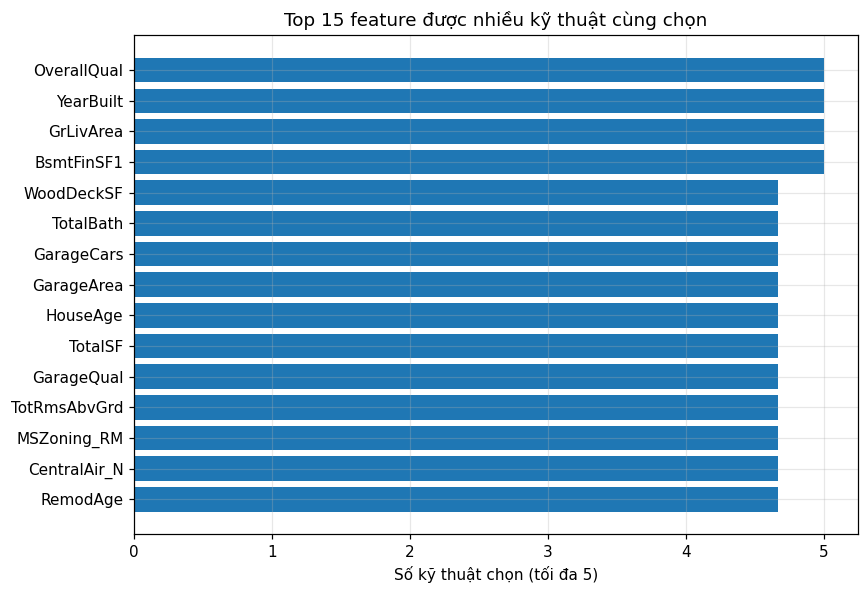

,filter_kbest,filter_mi,wrapper_rfe|SVR,wrapper_rfe|RandomForest,wrapper_rfe|XGBoost,embedded_lasso,embedded_rf
filter_kbest,50,43,8,35,33,19,34
filter_mi,43,50,6,41,36,18,39
wrapper_rfe|SVR,8,6,50,7,13,25,8
wrapper_rfe|RandomForest,35,41,7,50,39,19,45
wrapper_rfe|XGBoost,33,36,13,39,50,26,39
embedded_lasso,19,18,25,19,26,50,20
embedded_rf,34,39,8,45,39,20,50


In [7]:
mp = DATA / 'selected_features_matrix.csv'
if mp.exists():
    M = pd.read_csv(mp, index_col=0)
    rfe_cols = [c for c in M.columns if c.startswith('wrapper_rfe')]
    score = (M['filter_kbest'] + M['filter_mi'] + M['embedded_lasso'] + M['embedded_rf']
             + M[rfe_cols].mean(axis=1))            # 0..5, RFE tính theo tỉ lệ 3 mô hình
    agree = score.sort_values(ascending=False).rename('so_ky_thuat_chon (0-5)').to_frame()
    agree.to_csv(DATA / 'feature_agreement.csv')
    print('Feature được chọn bởi >= 4/5 kỹ thuật:', int((score >= 4).sum()),
          '| >= 3/5:', int((score >= 3).sum()), '| không kỹ thuật nào chọn:', int((score == 0).sum()))
    top = agree.head(15).iloc[::-1]
    plt.figure(figsize=(8, 5.5)); plt.barh(top.index, top.iloc[:, 0])
    plt.xlabel('Số kỹ thuật chọn (tối đa 5)'); plt.title('Top 15 feature được nhiều kỹ thuật cùng chọn')
    plt.tight_layout(); plt.savefig(FIG / 'fig7_feature_agreement.png', dpi=150); plt.show()
    pairs = {}
    sets = {c: set(M.index[M[c] == 1]) for c in M.columns}
    names = list(sets)
    ov = pd.DataFrame([[len(sets[a] & sets[b]) for b in names] for a in names], index=names, columns=names)
    display(ov)
else:
    print('Chưa có selected_features_matrix.csv – chờ TV5 xuất, rồi chạy lại ô này.')

## 7. Cấu hình tốt nhất cho từng mô hình (số liệu điền vào báo cáo)

In [8]:
for m in MODELS:
    s = rk[rk.model == m].sort_values('cv_log_rmse')
    b, bl = s.iloc[0], s[s.technique == 'baseline'].iloc[0]
    fs_only = s[s.technique != 'baseline'].iloc[0]
    print(f"{m:13s} | tốt nhất tổng thể: {b.technique:15s} CV {b.cv_log_rmse:.4f} ({b.pct_vs_baseline:+.2f}%)"
          f" | tốt nhất trong 5 kỹ thuật FS: {fs_only.technique:15s} CV {fs_only.cv_log_rmse:.4f} ({fs_only.pct_vs_baseline:+.2f}%)"
          f" | baseline {bl.cv_log_rmse:.4f} ({int(bl.n_features)} feature)")
print()
slow, fast = rk.sort_values('cv_seconds').iloc[-1], rk.sort_values('cv_seconds').iloc[0]
print(f'Chậm nhất: {slow.technique} + {slow.model} ({slow.cv_seconds:.0f}s) | nhanh nhất: {fast.technique} + {fast.model} ({fast.cv_seconds:.1f}s)')

SVR           | tốt nhất tổng thể: embedded_lasso  CV 0.1146 (-3.12%) | tốt nhất trong 5 kỹ thuật FS: embedded_lasso  CV 0.1146 (-3.12%) | baseline 0.1183 (262 feature)
RandomForest  | tốt nhất tổng thể: embedded_lasso  CV 0.1293 (-0.68%) | tốt nhất trong 5 kỹ thuật FS: embedded_lasso  CV 0.1293 (-0.68%) | baseline 0.1301 (262 feature)
XGBoost       | tốt nhất tổng thể: baseline        CV 0.1160 (+0.00%) | tốt nhất trong 5 kỹ thuật FS: wrapper_rfe     CV 0.1161 (+0.11%) | baseline 0.1160 (262 feature)

Chậm nhất: wrapper_rfe + RandomForest (84s) | nhanh nhất: filter_kbest + SVR (0.3s)
